In [3]:
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
!pip install -r requirements.txt

Cloning into 'yolov5'...
remote: Enumerating objects: 18359, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 18359 (delta 39), reused 23 (delta 17), pack-reused 18274 (from 2)
Receiving objects: 100% (18359/18359), 17.58 MiB | 16.10 MiB/s, done.
Resolving deltas: 100% (12465/12465), done.
/content/yolov5
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 16.0 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0


In [4]:
!pip install -q roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 139.8 MB/s eta 0:00:00


In [6]:
from google.colab import userdata

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')

from roboflow import Roboflow

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("2026-oss").project("ai-picture-book-object-detection")
dataset = project.version(2).download("yolov5")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to AI-Picture-Book-Object-Detection-2 in yolov5pytorch:: 100%|██████████| 1445/1445 [00:00<00:00, 8713.12it/s]


In [7]:
!ls

AI-Picture-Book-Object-Detection-2  export.py	     requirements.txt
benchmarks.py			    hubconf.py	     segment
CITATION.cff			    LICENSE	     tests
classify			    models	     train.py
CONTRIBUTING.md			    pyproject.toml   tutorial.ipynb
data				    README.md	     utils
detect.py			    README.zh-CN.md  val.py


In [9]:
!find . -name "data.yaml"

./AI-Picture-Book-Object-Detection-2/data.yaml


In [8]:
!ls AI-Picture-Book-Object-Detection-2

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [20]:
yaml_path = "./AI-Picture-Book-Object-Detection-2/data.yaml"

with open(yaml_path, "r") as f:
    data = f.read()

data = data.replace("train: train/images", "train: ./AI-Picture-Book-Object-Detection-2/train/images")
data = data.replace("val: valid/images", "val: ./AI-Picture-Book-Object-Detection-2/valid/images")
data = data.replace("test: test/images", "test: ./AI-Picture-Book-Object-Detection-2/test/images")

with open(yaml_path, "w") as f:
    f.write(data)

!cat ./AI-Picture-Book-Object-Detection-2/data.yaml

names:
- book_flowerpot
- book_monkey
- braille
- tactile_flowerpot
- tactile_monkey
- text
nc: 6
roboflow:
  license: MIT
  project: ai-picture-book-object-detection
  url: https://universe.roboflow.com/2026-oss/ai-picture-book-object-detection/dataset/2
  version: 2
  workspace: 2026-oss
test: ./AI-Picture-Book-Object-Detection-2/test/images
train: ./AI-Picture-Book-Object-Detection-2/train/images
val: ./AI-Picture-Book-Object-Detection-2/valid/images


In [21]:
!ls AI-Picture-Book-Object-Detection-2/train/images | head
!ls AI-Picture-Book-Object-Detection-2/valid/images | head
!ls AI-Picture-Book-Object-Detection-2/test/images | head

book_flowerpot_0003_jpeg.rf.49fb2ae1128518aadea729ec5667a346.jpg
book_flowerpot_0003_jpeg.rf.6edceb513516480a898d72a72975940f.jpg
book_flowerpot_0003_jpeg.rf.ab0dc42ae5c0dbcc305f9cfcc2b83243.jpg
book_flowerpot_0004_jpeg.rf.2fd521b414d5fd4b3c35d5ca67aed9f0.jpg
book_flowerpot_0004_jpeg.rf.9712d55cc60b6087247e48f9e7c0fc5a.jpg
book_flowerpot_0004_jpeg.rf.f329d74655c5efde1dbc24cf12d8486c.jpg
book_flowerpot_0006_jpg.rf.07e5a847cc502f1d22e8ff5ec1ed1515.jpg
book_flowerpot_0006_jpg.rf.23dabcd02a45db5b3e9c2f2e20ee1545.jpg
book_flowerpot_0006_jpg.rf.62399f58423337fe509cf1d0a1a449e3.jpg
book_flowerpot_0007_jpeg.rf.03271fbe48a04efea90edcdcafd2d396.jpg
book_flowerpot_0002_jpg.rf.d4c5d8f47b6c8b644001209271513536.jpg
book_flowerpot_0005_jpeg.rf.119589707c3f4210fba2c9931160bc5e.jpg
book_flowerpot_0015_jpeg.rf.269e478c6e6242ff8f2c3a4c1a08125b.jpg
book_flowerpot_0034_jpeg.rf.cb07a2110bb29606ed661ccb323d10dd.jpg
book_flowerpot_0039_jpg.rf.7bef3cc867881df7a89b1d96cb5800b9.jpg
book_monkey_00012_jpeg.rf.a514

In [22]:
!nvidia-smi

Sat Jun 13 16:17:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [23]:
!wget https://github.com/ultralytics/yolov5/releases/download/v7.0/yolov5s.pt

--2026-06-13 16:17:02--  https://github.com/ultralytics/yolov5/releases/download/v7.0/yolov5s.pt
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/264818686/381bd8a8-8910-4e9e-b0dd-2752951ef78c?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-06-13T17%3A06%3A42Z&rscd=attachment%3B+filename%3Dyolov5s.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-06-13T16%3A06%3A19Z&ske=2026-06-13T17%3A06%3A42Z&sks=b&skv=2018-11-09&sig=D76uWBFnrOPZbIWvUBI2LTvFkj1phhjHEnSCyBGJouc%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4MTM2OTIyMywibmJmIjoxNzgxMzY3NDIzLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNvcmUud2l

In [24]:
!python train.py \
--img 640 \
--batch 16 \
--epochs 100 \
--data ./AI-Picture-Book-Object-Detection-2/data.yaml \
--weights yolov5s.pt \
--name picture_book_yolov5

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
      41/99       4.5G    0.03413    0.01207   0.003561         40        640:  38% 15/40 [00:04<00:09,  2.77it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      41/99       4.5G     0.0342    0.01218   0.003634         32        640:  40% 16/40 [00:04<00:07,  3.04it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      41/99       4.5G    0.03423    0.01207   0.003794         32        640:  42% 17/40 [00:05<00:08,  2.79it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      41/99       4.5G    0.03405    0.01219   0.003

In [25]:
!ls runs/train

picture_book_yolov5  picture_book_yolov52


In [28]:
!python detect.py \
--weights runs/train/picture_book_yolov52/weights/best.pt \
--conf 0.25 \
--source /content/yolov5/AI-Picture-Book-Object-Detection-2/test/images

detect: weights=['runs/train/picture_book_yolov52/weights/best.pt'], source=/content/yolov5/AI-Picture-Book-Object-Detection-2/test/images, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-503-gb8493964 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7026307 parameters, 0 gradients, 15.8 GFLOPs
image 1/30 /content/yolov5/AI-Picture-Book-Object-Detection-2/test/images/book_flowerpot_0001_jpeg.rf.bd70f4fbdee01021e3ae1d7a7ecc9374.jpg: 640x640 1 book_flowerpot, 10.9ms
image 2/30 /content/yolov5/AI-Picture-Book-Object-Detection-2/test/images/book_f

Best weights: runs/train/picture_book_yolov52/weights/best.pt
detect: weights=['runs/train/picture_book_yolov52/weights/best.pt'], source=./AI-Picture-Book-Object-Detection-2/test/images, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-503-gb8493964 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7026307 parameters, 0 gradients, 15.8 GFLOPs
image 1/30 /content/yolov5/AI-Picture-Book-Object-Detection-2/test/images/book_flowerpot_0001_jpeg.rf.bd70f4fbdee01021e3ae1d7a7ecc9374.jpg: 640x640 1 book_flowerpot, 11.4ms
image 2/30 /content/yolov5/AI-Pi

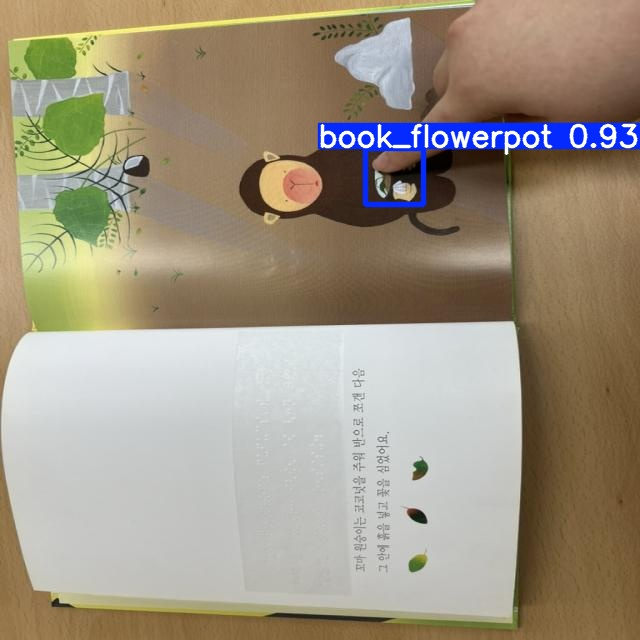

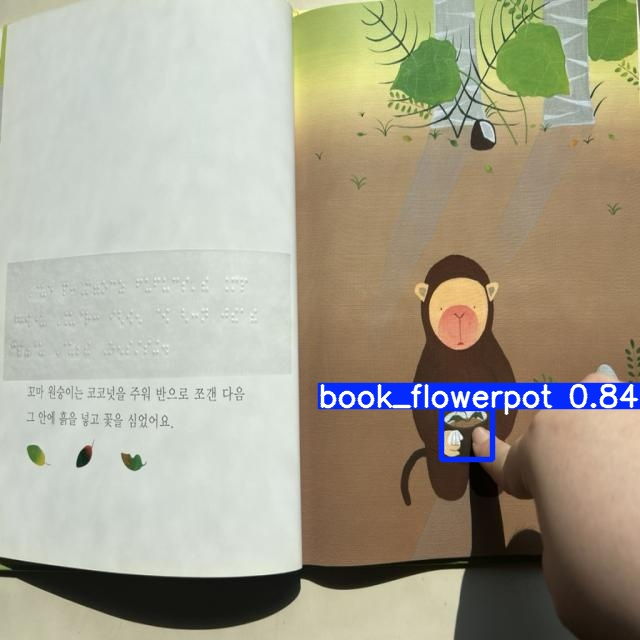

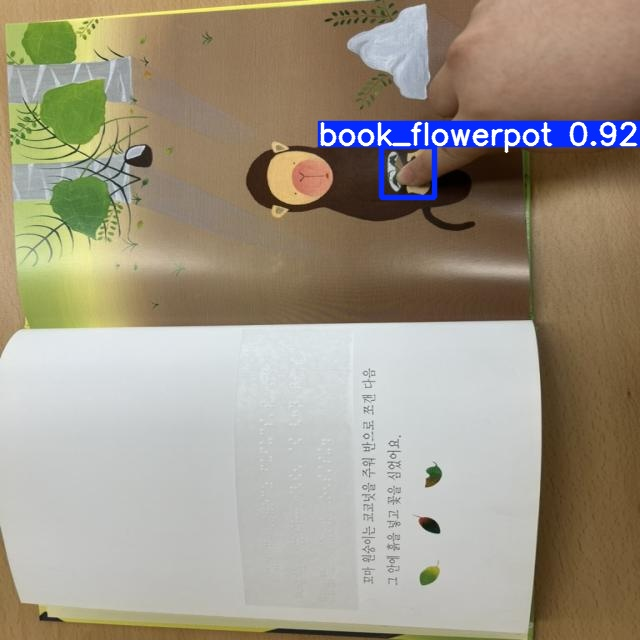

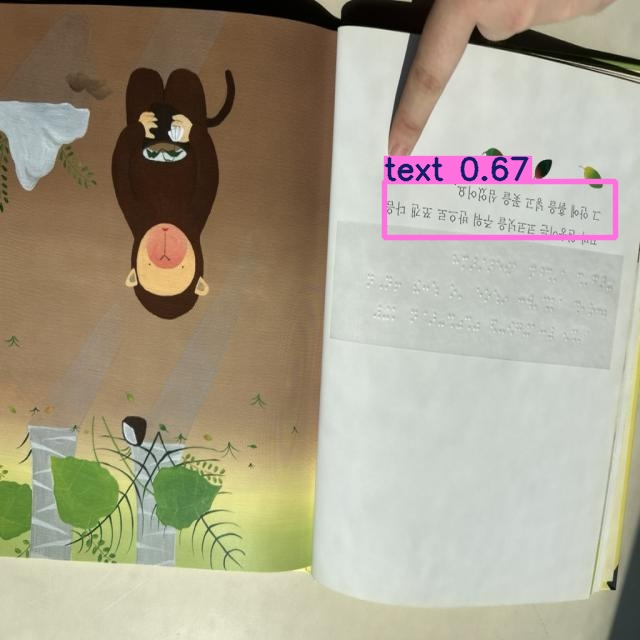

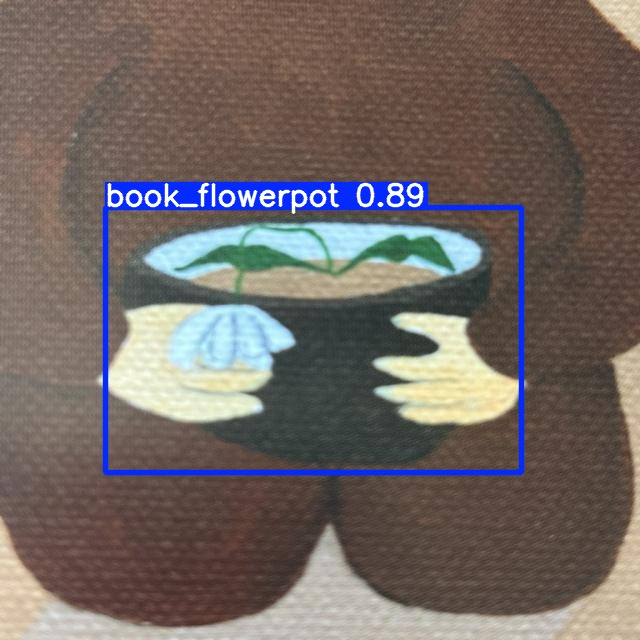

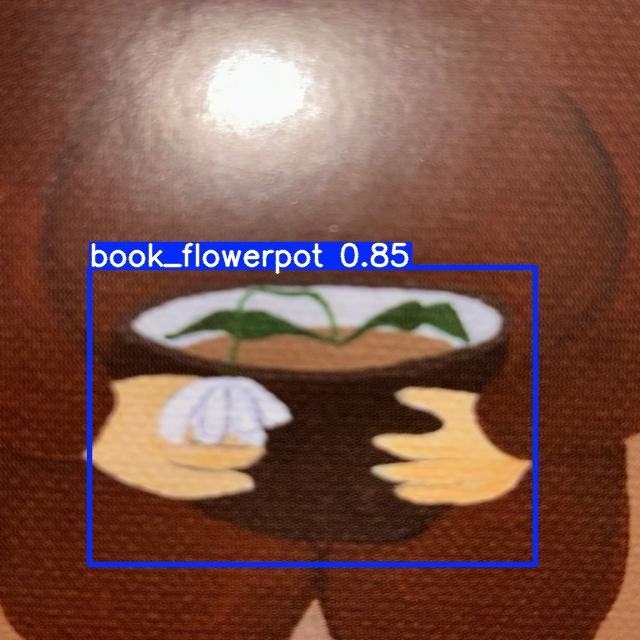

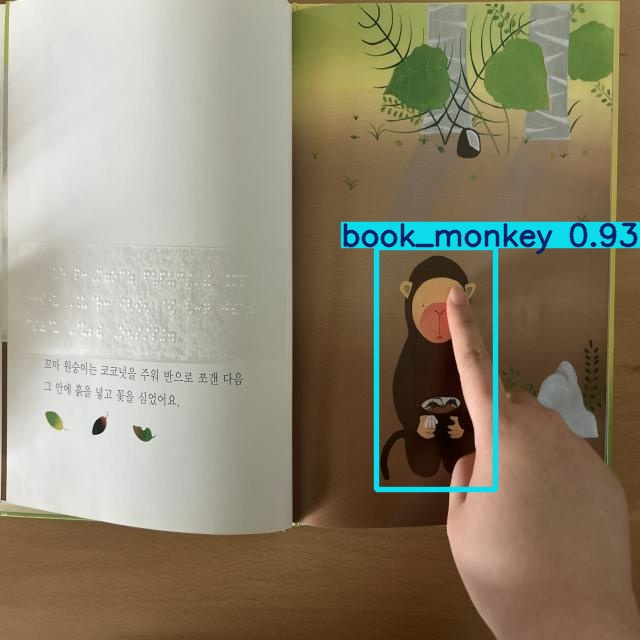

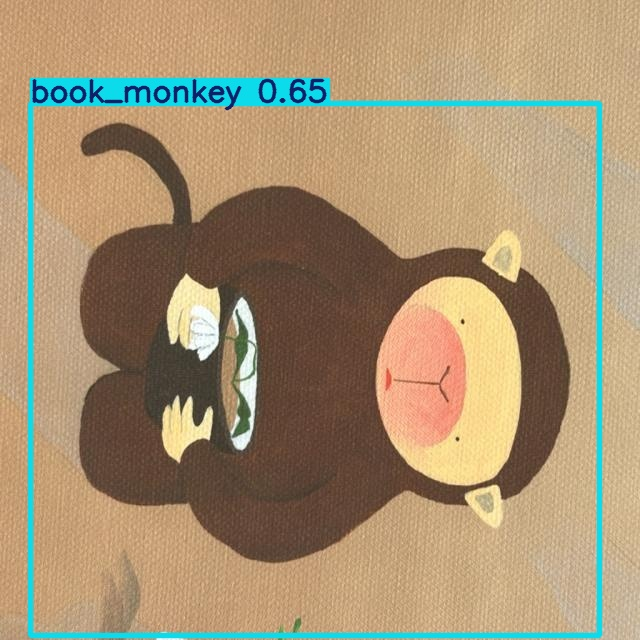

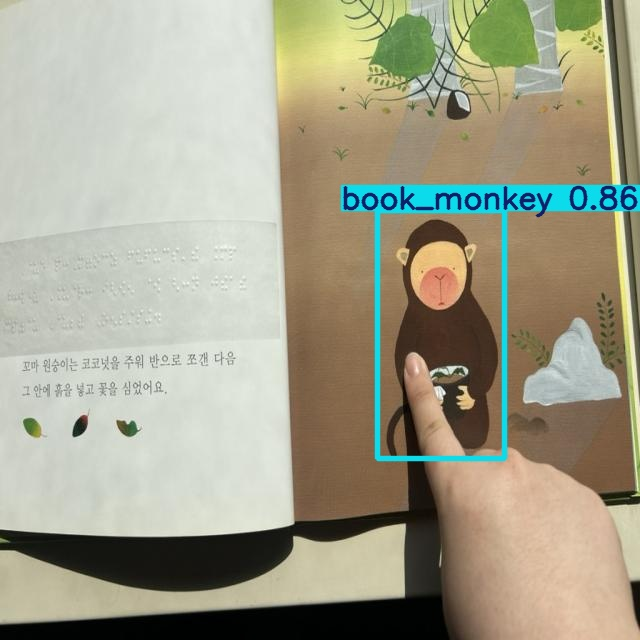

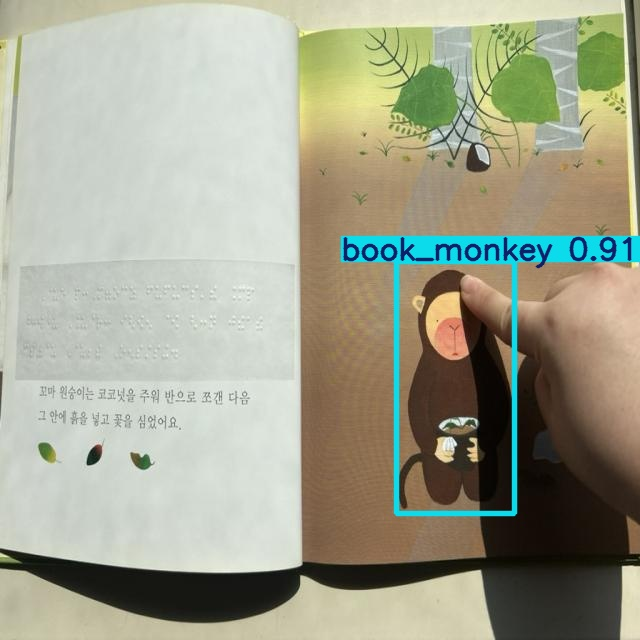

val: data=./AI-Picture-Book-Object-Detection-2/data.yaml, weights=['runs/train/picture_book_yolov52/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=test, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False
YOLOv5 🚀 v7.0-503-gb8493964 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7026307 parameters, 0 gradients, 15.8 GFLOPs
test: Scanning /content/yolov5/AI-Picture-Book-Object-Detection-2/test/labels.cache... 30 images, 0 backgrounds, 0 corrupt: 100% 30/30 [00:00<?, ?it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% 1/1 [00:01<00:00,  1.13s/it]
                   all         30         31      0.847      0.889      0.898      0.641
        book_flowerpot         30          6     

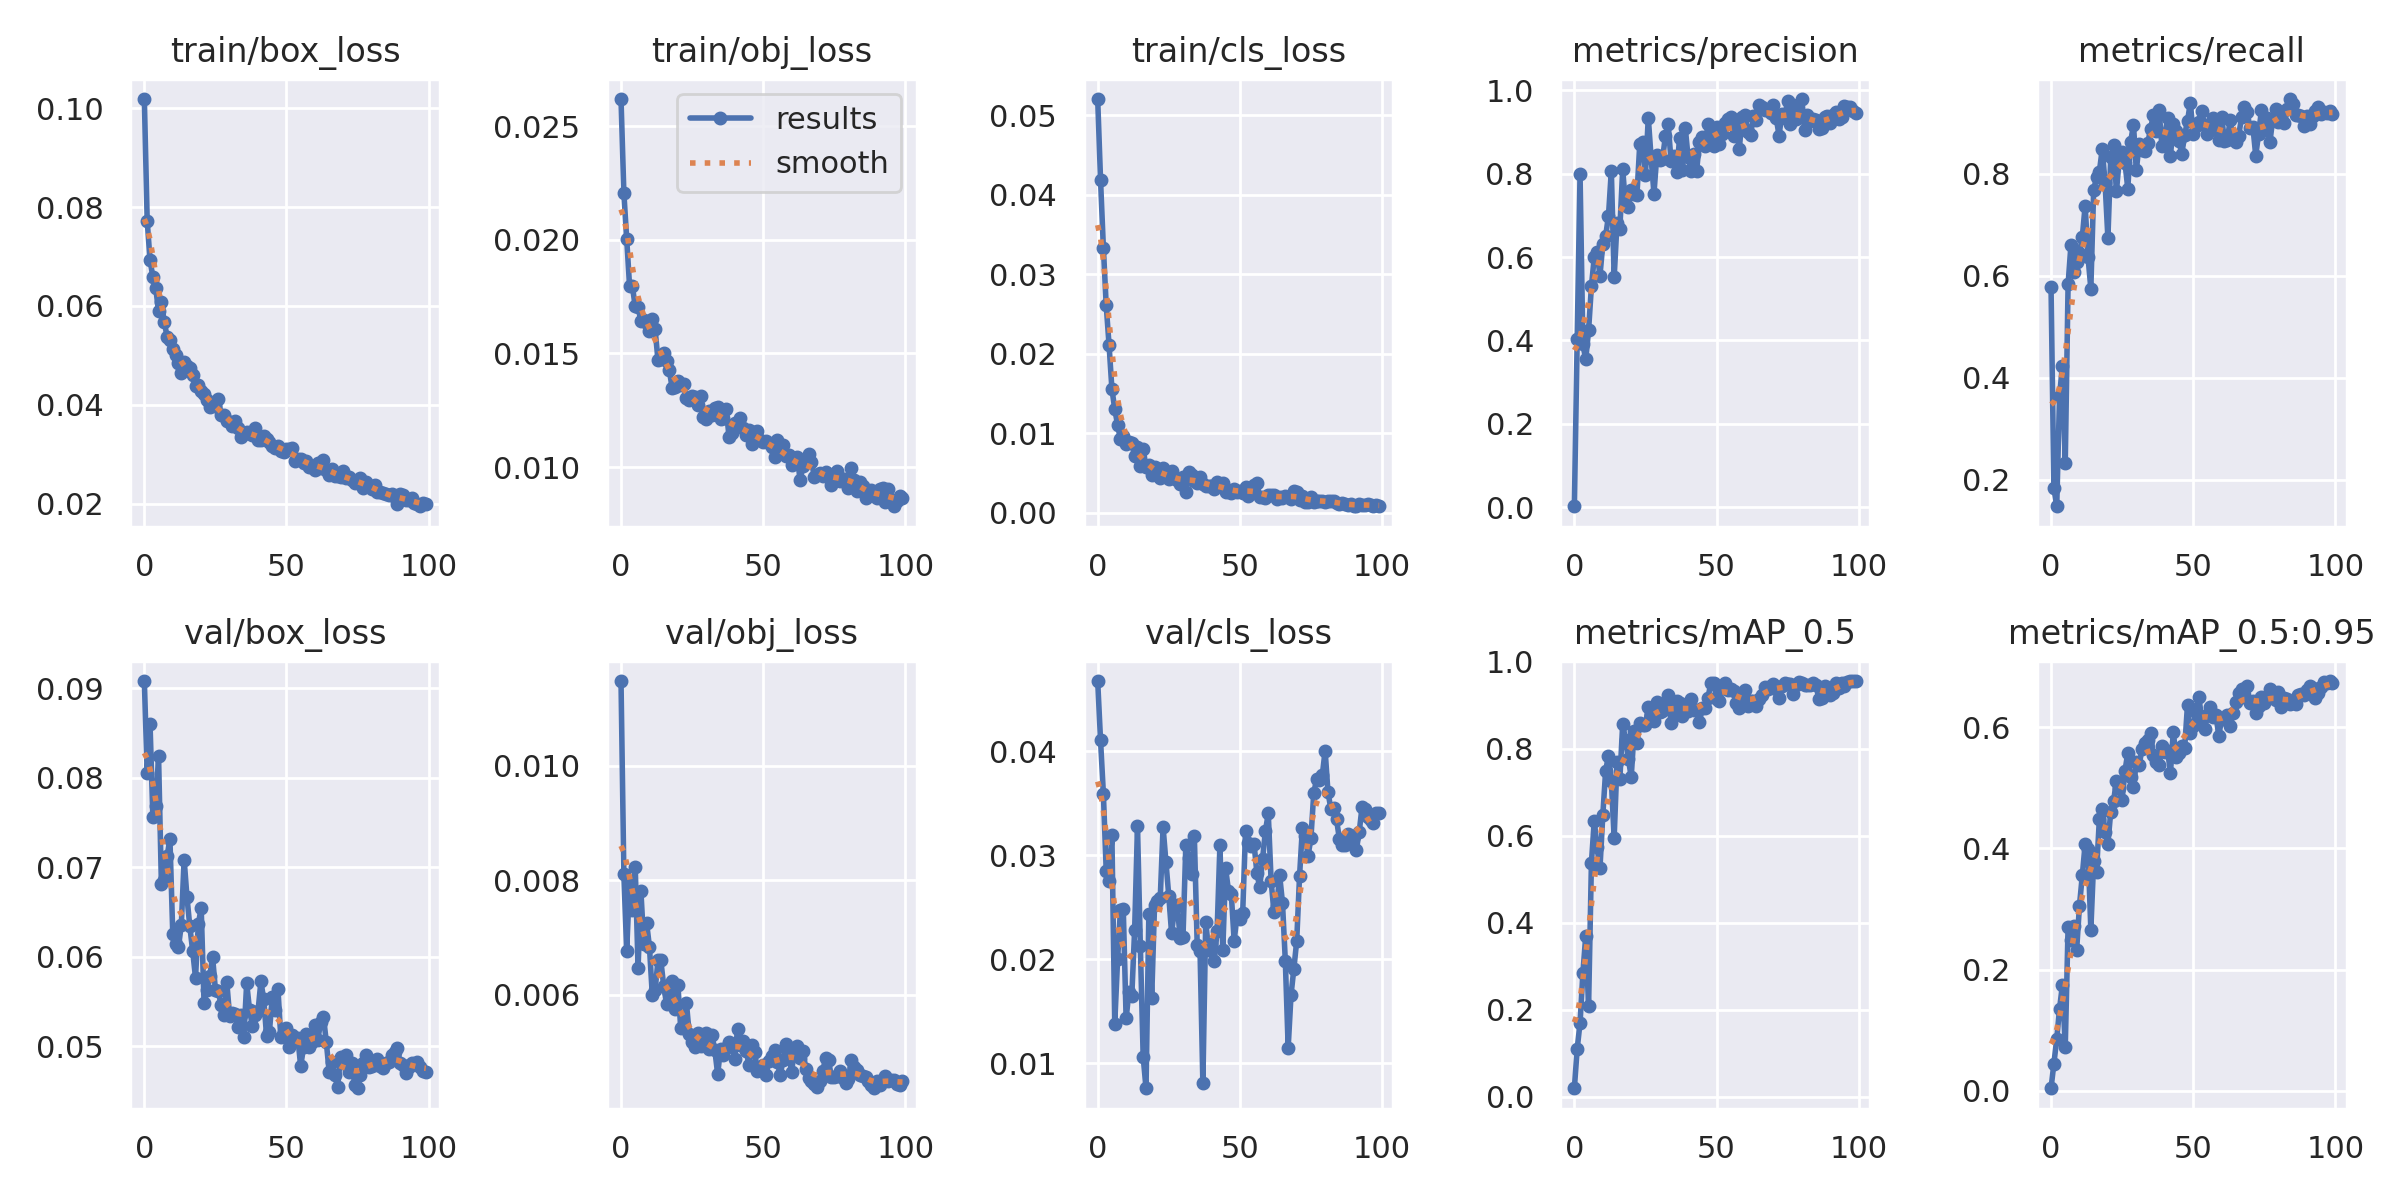

In [30]:
import glob
from IPython.display import Image, display

# 가장 최근 학습된 best.pt 찾기
best_weights = sorted(glob.glob("runs/train/*/weights/best.pt"))[-1]
print("Best weights:", best_weights)

# 테스트 이미지 추론
!python detect.py \
--weights {best_weights} \
--conf 0.25 \
--source ./AI-Picture-Book-Object-Detection-2/test/images

# 추론 결과 확인
results = sorted(glob.glob("runs/detect/exp*/*.jpg"))

print(f"Detected Images: {len(results)}")

for img in results[:10]:
    display(Image(filename=img))

# Test Dataset 평가
!python val.py \
--weights {best_weights} \
--data ./AI-Picture-Book-Object-Detection-2/data.yaml \
--img 640 \
--task test

# 학습 결과 그래프 표시
result_imgs = sorted(glob.glob("runs/train/*/results.png"))

if result_imgs:
    print("Training Result:", result_imgs[-1])
    display(Image(filename=result_imgs[-1]))
else:
    print("results.png 파일을 찾지 못했습니다.")